# Laboratory work 1

### Dependencies

In [1]:
%matplotlib ipympl

import mujoco
import time
import itertools
import numpy as np
from numpy import pi, sin, cos
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import enum
from tqdm import tqdm

import os
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['__NV_PRIME_RENDER_OFFLOAD'] = '1'
os.environ['__GLX_VENDOR_LIBRARY_NAME'] = 'nvidia'

model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm.xml")
model_xml = model_dir / "scene_arm.xml"
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
# camera.azimuth = -90
# camera.elevation = 0
camera.distance = 3

renderer = mujoco.Renderer(model, height=h, width=w)

### Init

In [2]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1", "arm_f1x"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1", "arm_link_fngr"]

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    def add_theta(self, q):
        self.theta += q
    def reset_theta(self):
        self.theta = np.zeros(6)
        self.theta[2] = pi/2
    def T_matrix(self, i):
        return np.array([
            [cos(self.theta[i]),    -sin(self.theta[i])*cos(self.alpha[i]),     sin(self.theta[i])*sin(self.alpha[i]),      self.a[i]*cos(self.theta[i])],
            [sin(self.theta[i]),    cos(self.theta[i])*cos(self.alpha[i]),      -cos(self.theta[i])*sin(self.alpha[i]),     self.a[i]*sin(self.theta[i])],
            [0,                     sin(self.alpha[i]),                         cos(self.alpha[i]),                         self.d[i]],
            [0,                     0,                                          0,                                          1]
            ])


l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117
h6 = 0.015

DH = DH_params()
DH.alpha = np.array([   -pi/2,  0,      pi/2,   -pi/2,  pi/2,   pi/2])
DH.a = np.array([       0,      l2,     -h3,    0,      0,      -h6])
DH.d = np.array([       0,      0,      0,      l3,     0,      l5])
DH.theta = np.array([   0.,     0.,     pi/2,   0.,     0.,     0.])


def calc_Jacobian(DH_params, p_endeff):
    J = np.zeros((6, 6))
    T = np.eye(4)
    for i in range(6):
        z_i = T[0:3, 2]
        p_i = T[0:3, 3]
        J[0:3, i] = np.cross(z_i, (p_endeff - p_i))
        J[3:6, i] = z_i
        A = DH_params.T_matrix(i)
        T = T @ A
    return J

def print_p_q(bodies, joints):
    p0 = data.body("arm_link_sh0").xpos
    for body, joint in zip(bodies, joints):
        print(f'{body}\t{np.round(data.body(body).xpos - p0, 3)}\t{np.round(data.joint(joint).qpos, 3)}')

def forward_kinematics(DH_params, count):
    T = np.eye(4)
    for i in range(count):
        A = DH.T_matrix(i)
        T = T @ A
    return T

def reset_position(data, joints, DH):
    set_q = np.array([0., 0., 0., 0., 0., 0.])
    for i, joint in zip(range(0, 6), joints):
        data.joint(joint).qpos = set_q[i]
    DH.reset_theta()

def set_position(data, joints, set_q, DH):
    reset_position(data, joints, DH)
    for i, joint in zip(range(0, 6), joints):
        data.joint(joint).qpos = set_q[i]
    DH.add_theta(set_q)

def calc_euler(R):
    theta = np.arccos(R[2, 2])
    if ((R[2, 2] != 1) and (R[2, 2] != -1)):
        phi = np.atan2(R[1, 2], R[0, 2])
        psi = np.atan2(R[2, 1], -R[2, 0])
    elif (R[2, 2] == 1):
        psi = 0
        theta = np.atan2(R[1, 0], R[0, 0])
    elif (R[2, 2] == -1):
        psi = 0
        theta = np.atan2(-R[0, 1], R[0, 0])
    return phi, theta, psi

### Forward Kinematics

* Zero position:

""

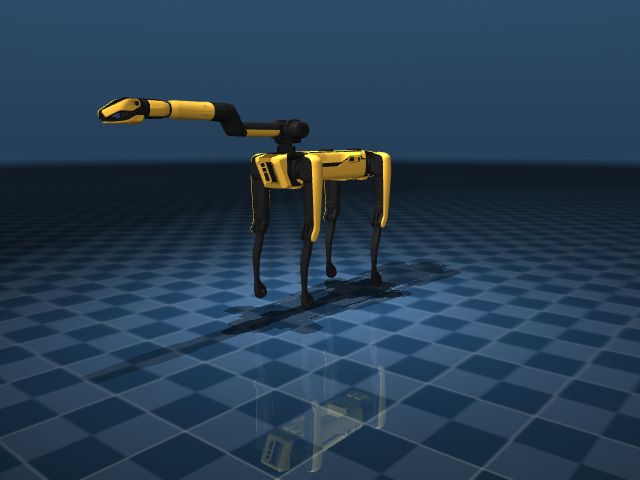

arm_link_sh0	[0. 0. 0.]	[0.]
arm_link_sh1	[0. 0. 0.]	[0.]
arm_link_el0	[0.339 0.    0.   ]	[0.]
arm_link_el1	[0.742 0.    0.075]	[0.]
arm_link_wr0	[0.742 0.    0.075]	[0.]
arm_link_wr1	[0.742 0.    0.075]	[0.]
arm_link_fngr	[0.859 0.    0.09 ]	[0.]

Try forward kinematics: [0.859 0.    0.09 ]
phi:	-1.571
theta:	1.571
psi:	0.0


In [3]:
mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

reset_position(data, joints, DH)
print_p_q(bodies, joints)

T = forward_kinematics(DH, 6)
print(f'\nTry forward kinematics: {np.round(T[0:3, 3], 3)}')

R = T[0:3, 0:3]
phi, theta, psi = calc_euler(R)
print(f'phi:\t{np.round(phi,3)}\ntheta:\t{np.round(theta,3)}\npsi:\t{np.round(psi,3)}')

* Custom position:

""

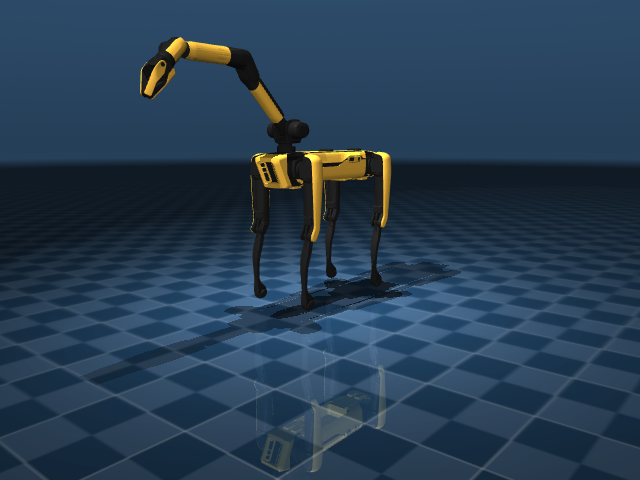

arm_link_sh0	[0. 0. 0.]	[0.]
arm_link_sh1	[0. 0. 0.]	[-0.785]
arm_link_el0	[0.239 0.    0.239]	[0.785]
arm_link_el1	[0.643 0.    0.314]	[0.]
arm_link_wr0	[0.643 0.    0.314]	[0.785]
arm_link_wr1	[0.643 0.    0.314]	[0.]
arm_link_fngr	[0.736 0.    0.242]	[0.]
Try FK:	[0.736 0.    0.243]
phi:	-1.571
theta:	1.571
psi:	-0.785


In [4]:
set_q = np.array([0., -pi/4, pi/4, 0., pi/4, 0.])
set_position(data, joints, set_q, DH)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

print_p_q(bodies, joints)
T = forward_kinematics(DH, 6)
print(f'Try FK:\t{np.round(T[0:3, 3], 3)}')

R = T[0:3, 0:3]
phi, theta, psi = calc_euler(R)
print(f'phi:\t{np.round(phi,3)}\ntheta:\t{np.round(theta,3)}\npsi:\t{np.round(psi,3)}')

reset_position(data, joints, DH)

### Inverse Kinematics

p4:	[ 0.615 -0.     0.422]
q123:	-0.0	-0.5	-0.0
q456:	0.0	0.5	0.0


""

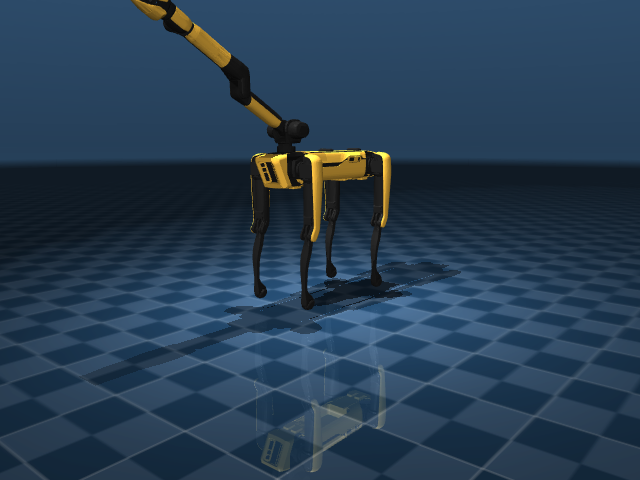

arm_link_sh0	[0. 0. 0.]	[0.]
arm_link_sh1	[0. 0. 0.]	[-0.5]
arm_link_el0	[0.297 0.    0.162]	[0.]
arm_link_el1	[0.615 0.    0.421]	[0.]
arm_link_wr0	[0.615 0.    0.421]	[0.]
arm_link_wr1	[0.615 0.    0.421]	[0.]
arm_link_fngr	[0.711 0.    0.491]	[0.]


In [5]:
set_q = np.array([0., -0.5, 0., 0., 0., 0.])
set_position(data, joints, set_q, DH)
# reset_position(data, joints, DH)

T4 = np.eye(4)
for i in range(4):
    A = DH.T_matrix(i)
    T4 = T4 @ A
p4 = T4[0:3, 3]
print(f'p4:\t{np.round(p4, 3)}')

b = p4[2]
c = np.sqrt(p4[0]**2 + p4[1]**2)
d4 = np.sqrt(l3**2 + h3**2)
beta = np.atan2(l3, h3)
theta3s = np.arccos((d4**2 + l2 **2 - b**2 - c**2) / (2 * d4 * l2))
alpha = np.atan2(b, c)
a = np.sqrt(b**2 + c**2)
gamma = np.arccos((a**2 + l2**2 - d4**2) / (2 * a * l2))


q1 = np.atan2(p4[1], p4[0])
q2 = - (alpha - gamma)
q3 = - (pi - theta3s - (pi/2 - beta))
print(f'q123:\t{np.round(q1, 3)}\t{np.round(q2, 3)}\t{np.round(q3, 3)}')

R03 = T4[0:3, 0:3]
R36 = np.matmul(np.transpose(R03), R)     # R is R06

q4 = np.atan2(np.sqrt(1 - (R36[2, 2])**2), R[2, 2]) - pi
q5 = np.atan2(R36[1, 2], R36[0, 2]) + pi/4
q6 = np.atan2(R36[2, 1], -R36[2, 0]) - pi/2
print(f'q456:\t{np.round(q4, 3)}\t{np.round(q5, 3)}\t{np.round(q6, 3)}')


mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

print_p_q(bodies, joints)